In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from pathlib import Path

file_path = Path("../data/processed/student_performance_model_data.csv")

df = pd.read_csv(file_path)

df.head()

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
0,18.5,95.6,3.8,97.9
1,14.0,80.0,2.5,83.9
2,19.5,86.3,5.3,100.0
3,25.7,70.2,7.0,100.0
4,13.4,81.9,6.9,92.0


In [5]:
X = df[
    [
        "weekly_self_study_hours",
        "attendance_percentage",
        "class_participation"
    ]
]

y = df["total_score"]

In [6]:
df["study_attendance_interaction"] = (
    df["weekly_self_study_hours"] *
    df["attendance_percentage"]
)

In [7]:
df["engagement_score"] = (
    df["attendance_percentage"] +
    df["class_participation"]
) / 2

In [8]:
df[
    [
        "weekly_self_study_hours",
        "attendance_percentage",
        "class_participation",
        "study_attendance_interaction",
        "engagement_score",
        "total_score"
    ]
].head()

,weekly_self_study_hours,attendance_percentage,class_participation,study_attendance_interaction,engagement_score,total_score
0,18.5,95.6,3.8,1768.60,49.70,97.9
1,14.0,80.0,2.5,1120.00,41.25,83.9
2,19.5,86.3,5.3,1682.85,45.80,100.0
3,25.7,70.2,7.0,1804.14,38.60,100.0
4,13.4,81.9,6.9,1097.46,44.40,92.0


In [9]:
df[
    [
        "study_attendance_interaction",
        "engagement_score"
    ]
].describe()

,study_attendance_interaction,engagement_score
count,5010.000000,5010.000000
mean,1275.061178,45.325180
std,601.447228,4.793229
min,0.000000,27.600000
25%,854.735000,42.050000
50%,1253.975000,45.400000
75%,1669.720000,48.900000
max,3543.330000,55.000000


In [10]:
features = [
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation"
]

X = df[features]
y = df["total_score"]

In [11]:
print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Features (X):


,weekly_self_study_hours,attendance_percentage,class_participation
0,18.5,95.6,3.8
1,14.0,80.0,2.5
2,19.5,86.3,5.3
3,25.7,70.2,7.0
4,13.4,81.9,6.9



Target (y):


0     97.9
1     83.9
2    100.0
3    100.0
4     92.0
Name: total_score, dtype: float64

In [12]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5010, 3)
y shape: (5010,)


In [13]:
df["study_attendance_interaction"] = (
    df["weekly_self_study_hours"] *
    df["attendance_percentage"]
)

In [14]:
df[
    [
        "weekly_self_study_hours",
        "attendance_percentage",
        "study_attendance_interaction"
    ]
].head()

,weekly_self_study_hours,attendance_percentage,study_attendance_interaction
0,18.5,95.6,1768.60
1,14.0,80.0,1120.00
2,19.5,86.3,1682.85
3,25.7,70.2,1804.14
4,13.4,81.9,1097.46


In [15]:
df["study_attendance_interaction"].describe()

count    5010.000000
mean     1275.061178
std       601.447228
min         0.000000
25%       854.735000
50%      1253.975000
75%      1669.720000
max      3543.330000
Name: study_attendance_interaction, dtype: float64

In [16]:
df["engagement_score"] = (
    df["attendance_percentage"] +
    df["class_participation"]
) / 2

In [17]:
df["engagement_score"].describe()

count    5010.000000
mean       45.325180
std         4.793229
min        27.600000
25%        42.050000
50%        45.400000
75%        48.900000
max        55.000000
Name: engagement_score, dtype: float64

In [18]:
feature_columns = [
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation",
    "study_attendance_interaction",
    "engagement_score",
    "total_score"
]

correlation_matrix = df[feature_columns].corr()

correlation_matrix

,weekly_self_study_hours,attendance_percentage,class_participation,study_attendance_interaction,engagement_score,total_score
weekly_self_study_hours,1.000000,-0.019163,-0.033600,0.965694,-0.025695,0.809622
attendance_percentage,-0.019163,1.000000,-0.013619,0.217428,0.978789,-0.029022
class_participation,-0.033600,-0.013619,1.000000,-0.036875,0.191524,-0.032842
study_attendance_interaction,0.965694,0.217428,-0.036875,1.000000,0.205867,0.781173
engagement_score,-0.025695,0.978789,0.191524,0.205867,1.000000,-0.035216
total_score,0.809622,-0.029022,-0.032842,0.781173,-0.035216,1.000000


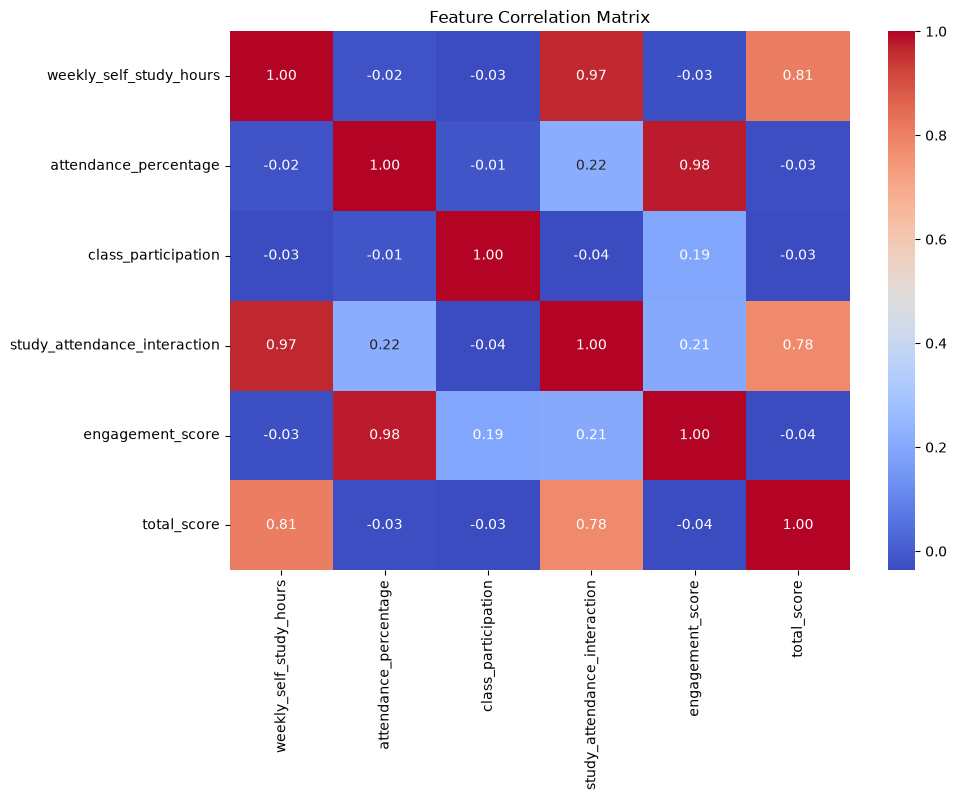

In [19]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [20]:
target_correlation = (
    correlation_matrix["total_score"]
    .sort_values(ascending=False)
)

target_correlation

total_score                     1.000000
weekly_self_study_hours         0.809622
study_attendance_interaction    0.781173
attendance_percentage          -0.029022
class_participation            -0.032842
engagement_score               -0.035216
Name: total_score, dtype: float64

In [21]:
predictor_correlation = correlation_matrix.drop(
    "total_score"
).drop(
    "total_score",
    axis=1
)

predictor_correlation

,weekly_self_study_hours,attendance_percentage,class_participation,study_attendance_interaction,engagement_score
weekly_self_study_hours,1.000000,-0.019163,-0.033600,0.965694,-0.025695
attendance_percentage,-0.019163,1.000000,-0.013619,0.217428,0.978789
class_participation,-0.033600,-0.013619,1.000000,-0.036875,0.191524
study_attendance_interaction,0.965694,0.217428,-0.036875,1.000000,0.205867
engagement_score,-0.025695,0.978789,0.191524,0.205867,1.000000


In [22]:
final_features = [
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation"
]

X = df[final_features]
y = df["total_score"]

In [23]:
engineered_df = df[
    [
        "weekly_self_study_hours",
        "attendance_percentage",
        "class_participation",
        "study_attendance_interaction",
        "engagement_score",
        "total_score"
    ]
]

engineered_df.head()

,weekly_self_study_hours,attendance_percentage,class_participation,study_attendance_interaction,engagement_score,total_score
0,18.5,95.6,3.8,1768.60,49.70,97.9
1,14.0,80.0,2.5,1120.00,41.25,83.9
2,19.5,86.3,5.3,1682.85,45.80,100.0
3,25.7,70.2,7.0,1804.14,38.60,100.0
4,13.4,81.9,6.9,1097.46,44.40,92.0


In [24]:
engineered_df.to_csv(
    "../data/processed/student_performance_engineered.csv",
    index=False
)